# Fitting on Chip Inductors (1-40 GHz)

This tutorial demonstrates how more complex models can be generated and fitted onto s-parameter data. For this tutorial we will use data from an electromagnetic simulation of this on-chip inductor typical in MMICs or RFICs.

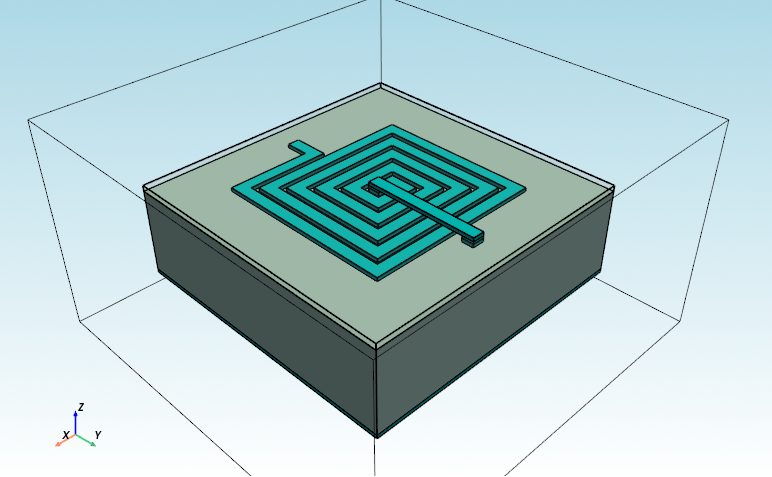


## The Equivalent Circuit

To accurately capture the complex parasitic behaviour of this model we will utilize the equivalent circuit outlined in the paper:
_"N-π Equivalent Circuit for Si CMOS on-Chip Inductor Modeling"_ [IEEE Link](https://ieeexplore.ieee.org/document/4534622). The circuit uses multiple repeated sections, each with many parameters which can be tuned to match the true response of the inductor.

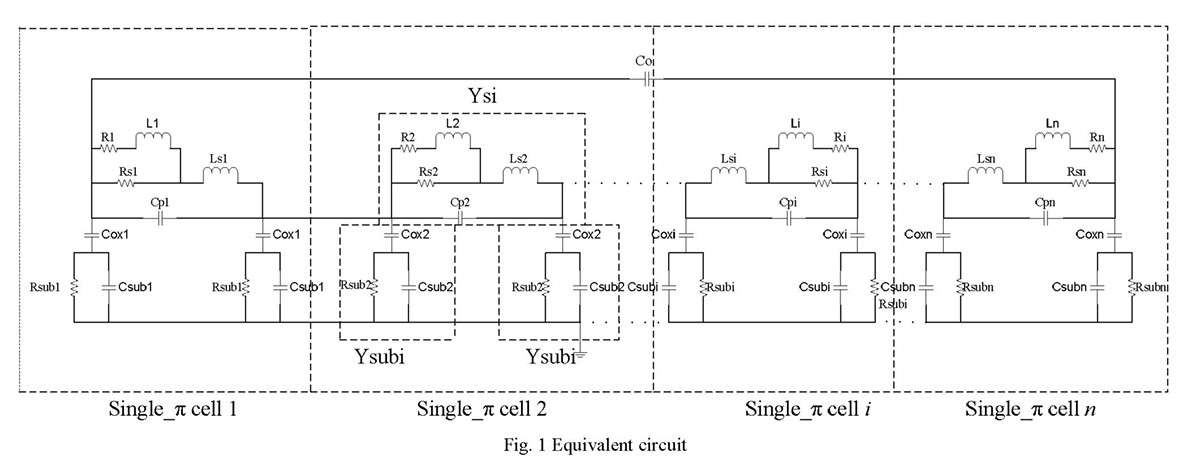

This is defined in 2 stages. 

Firstly, a single π cell can be defined as per the circuit diagram like this. 
Each individual component is first defined like `L1_model = pmrf.models.Inductor(L=L, name="L")`, and then you compose them into a circuit by creating a connection list and calling `pmrf.models.Circuit`.

In [7]:
import pmrf


def single_pi_cell(R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2, **kwargs):
    L1_model = pmrf.models.Inductor(L=L, name="L")
    Ls1_model = pmrf.models.Inductor(L=Ls, name="Ls")

    Cp1_model = pmrf.models.Capacitor(C=Cp, name="Cp")
    Cox1_model = pmrf.models.Capacitor(C=Cox1, name="Cox1")
    Cox2_model = pmrf.models.Capacitor(C=Cox2, name="Cox2")

    Csub1_model = pmrf.models.Capacitor(C=Csub1, name="Csub1")
    Csub2_model = pmrf.models.Capacitor(C=Csub2, name="Csub2")

    R1_model = pmrf.models.Resistor(R=R, name="R")
    Rs1_model = pmrf.models.Resistor(R=Rs, name="Rs")
    Rsub1_model = pmrf.models.Resistor(R=Rsub1, name="Rsub1")
    Rsub2_model = pmrf.models.Resistor(R=Rsub2, name="Rsub2")

    port1, port2 = pmrf.models.Port(), pmrf.models.Port()
    ground = pmrf.models.Ground()

    connections = [
        [(port1, 0), (Cox1_model, 1), (Cp1_model, 0), (R1_model, 0), (Rs1_model, 0)],
        [(R1_model, 1), (L1_model, 0)],
        [(L1_model, 1), (Rs1_model, 1), (Ls1_model, 0)],
        [(port2, 0), (Cox2_model, 1), (Cp1_model, 1), (Ls1_model, 1)],
        [(Cox1_model, 0), (Rsub1_model, 1), (Csub1_model, 1)],
        [(Cox2_model, 0), (Rsub2_model, 1), (Csub2_model, 1)],
        [
            (ground, 0),
            (Csub1_model, 0),
            (Csub2_model, 0),
            (Rsub1_model, 0),
            (Rsub2_model, 0),
        ],
    ]

    inductor_model = pmrf.models.Circuit(connections, **kwargs)

    return inductor_model


Secondly, this cell can now be reused any number of times to produce the complete model using a for loop and the cascade function. While doing so, we can automatically assign names to each cell to keep track of them later. Finally we insert the input-output capacitor by composing a basic circuit using the existing models. 

In [2]:
def multi_pi_cell(num, R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2, C0):
    if num <= 1:
        return single_pi_cell(R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2)

    models = []
    for i in range(num):
        models.append(
            single_pi_cell(R, L, Rs, Ls, Cp, Cox1, Cox2, Rsub1, Csub1, Rsub2, Csub2, name=f"cell{i}")
        )

    port1, port2 = pmrf.models.Port(), pmrf.models.Port()
    cascade = pmrf.models.Cascade(models)

    C0_model = pmrf.models.Capacitor(C=C0)

    connections = [
        [(port1, 0), (cascade, 0), (C0_model, 0)],
        [(port2, 0), (cascade, 1), (C0_model, 1)],
    ]

    return pmrf.models.Circuit(connections)


## Optimising the Model
Now to optimise the model we instantiate the model we have just defined, with `pmrf.bounded` parameters. This sets the upper and lower limits to be used for the optimisation. 

In [3]:
import pmrf

# Define model (N-Pi Equivalent Circuit for Si CMOS on-Chip Inductor Modeling)
inductor_model = multi_pi_cell(
    num=2,
    R=pmrf.Bounded(-1.0, 1000.0, value=0.0, scale=1.0),
    L=pmrf.Bounded(0.0, 5.0, value=0.5, scale=1e-9),
    Rs=pmrf.Bounded(-1.0, 1000.0, value=0.0, scale=1.0),
    Ls=pmrf.Bounded(0.0, 5.0, value=0.5, scale=1e-9),
    Cp=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    Cox1=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    Cox2=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    Rsub1=pmrf.Bounded(-1.0, 1000.0, value=0.0, scale=1.0),
    Csub1=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    Rsub2=pmrf.Bounded(-1.0, 1000.0, value=0.0, scale=1.0),
    Csub2=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
    C0=pmrf.Bounded(-1.0, 5.0, value=0.0, scale=1e-12),
)

Now we can simply load some s-parameter data and fit the model. Notice that it took 104 iterations and 23 seconds to fit. 

In [ ]:
import skrf

# Load Data
simulated_params = skrf.Network("./data/On chip inductor.s2p")
simulated_params = simulated_params["1-40GHz"]

# Fit
inductor_fit = pmrf.fitting.fit(inductor_model, simulated_params)

SciPy (default):   0%|          | 0/1024 [00:00<?, ?it/s]

## Reviewing the Fit
Now that you have got a fitted model you can show the results to compare the fit to the truth, showing excellent correlation.

Text(0.5, 1.0, 'Smith Chart - Model vs Simulated')

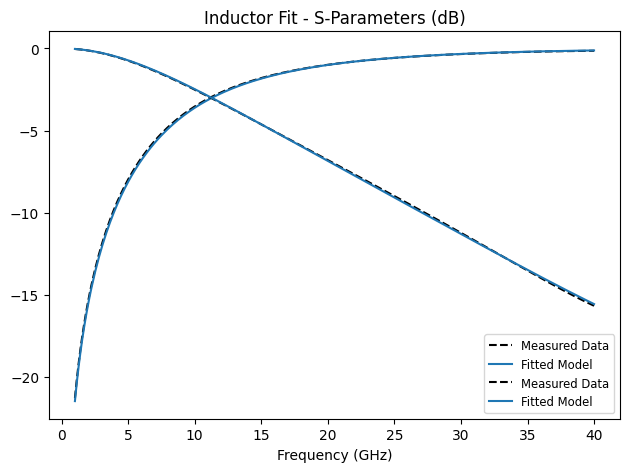

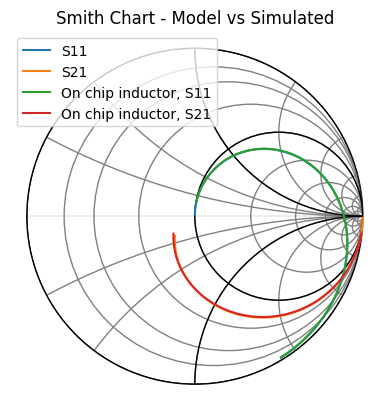

In [5]:
import matplotlib.pyplot as plt

# Plot 1 - S-parameter dB
fig1, ax1 = plt.subplots()
inductor_fit.plot_s_db(m=0, n=0, ax=ax1)
inductor_fit.plot_s_db(m=1, n=0, ax=ax1)
ax1.set_title("Inductor Fit - S-Parameters (dB)")

# Plot 2 - Smith Chart
fig2, ax2 = plt.subplots()
freq = pmrf.Frequency(0.1, 40, 1001, "GHz")
skrf_model = inductor_fit.model.to_skrf(frequency=freq)
skrf_model.plot_s_smith(m=0, n=0, ax=ax2)
skrf_model.plot_s_smith(m=1, n=0, ax=ax2)
simulated_params.plot_s_smith(m=0, n=0, ax=ax2)
simulated_params.plot_s_smith(m=1, n=0, ax=ax2)
ax2.set_title("Smith Chart - Model vs Simulated")

You can then print out the final fitted parameters.

In [6]:
import pprint

print("Final Fitted Parameters:")
pprint.pprint(inductor_fit.model.named_params())

Final Fitted Parameters:
{'cell0_Cox1.C': 4.678410549710832e-14,
 'cell0_Cox2.C': -1.0602026100081096e-14,
 'cell0_Cp.C': 2.808195716815165e-14,
 'cell0_Csub1.C': 0.0,
 'cell0_Csub2.C': -4.440892098500626e-28,
 'cell0_L.L': 4.999999999332583e-10,
 'cell0_Ls.L': 7.568692813559276e-10,
 'cell0_R.R': 5.042632977847461e-13,
 'cell0_Rs.R': 5.1923238277629125e-05,
 'cell0_Rsub1.R': -4.516289971034926e-05,
 'cell0_Rsub2.R': 4.6277722250520625e-05,
 'cell1_Cox1.C': -1.060202610026506e-14,
 'cell1_Cox2.C': 4.015414624647229e-14,
 'cell1_Cp.C': 1.0258530457593728e-14,
 'cell1_Csub1.C': 0.0,
 'cell1_Csub2.C': -6.094014182167484e-25,
 'cell1_L.L': 4.999999999286186e-10,
 'cell1_Ls.L': 7.541233787531111e-10,
 'cell1_R.R': 5.992983886926595e-13,
 'cell1_Rs.R': 0.0003114028848847372,
 'cell1_Rsub1.R': 4.627771508380896e-05,
 'cell1_Rsub2.R': -0.0002793871606513454,
 'circuit[2].C': -1.1071347025595868e-14}
